<img src="./traffic_banner.jpg" alt="Traffic Accident Banner" width="60%">

# US Traffic Accident Data Analysis

## Identifying Patterns and Risk Factors to Improve Road Safety

**Project 1: US Traffic Accidents**  
**Dataset:** US Accidents Dataset  
**Prepared by:** Anna Lunova
**Dataset Source:**  
This project uses the US Accidents dataset from Kaggle:  
[US Accidents Dataset - Kaggle](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents)

## Overview

This project analyzes the US Accidents dataset to better understand patterns in traffic accidents across the United States. The goal is to explore when, where, and under what conditions accidents are most likely to occur, then use those findings to develop practical recommendations for improving road safety.

In this notebook, I will clean and prepare the accident data, perform exploratory data analysis, create visualizations, and apply statistical analysis where appropriate. The analysis will focus on identifying meaningful trends related to accident severity, location, time, weather, and road conditions.

The final goal is to provide clear, data-driven insights that could help a Department of Transportation audience make better decisions about accident prevention, infrastructure planning, and public safety improvements.

### Bottom Line Up Front

This analysis found that traffic accidents are most common during weekday commute hours, especially around 7–8 AM and 4–5 PM. Accident volume is also concentrated in high-population states and cities, including California, Florida, Texas, Houston, Miami, and Los Angeles.

Most accidents are classified as Moderate severity, but nighttime accidents show slightly higher average severity and longer average duration than daytime accidents. Based on these findings, the main recommendations are to focus safety efforts during commute hours, prioritize high-accident locations, and improve nighttime visibility and response planning.

## Business Understanding

The Department of Transportation is responsible for improving road safety and reducing traffic accidents. Traffic accidents can create serious public safety problems, including injuries, deaths, traffic delays, property damage, and economic costs. Because of this, understanding accident patterns can help transportation leaders make better decisions about where to focus safety improvements.

The purpose of this project is to analyze traffic accident data and identify patterns that may help explain when, where, and why accidents happen. This analysis can support decisions related to infrastructure improvements, public safety campaigns, emergency response planning, and resource allocation.

For this project, the main business goal is to provide data-driven insights that could help reduce traffic accidents and improve road safety across the United States.

### Key Business Questions

This analysis will focus on the following questions:

1. When do traffic accidents occur most often?
2. Which locations or geographic areas have the highest number of accidents?
3. What weather or environmental conditions are associated with accident severity?
4. Are certain road features or traffic conditions related to more severe accidents?
5. What recommendations can be made to help reduce accidents and improve road safety?

### Stakeholders

The main stakeholders for this analysis include:

- Department of Transportation decision-makers
- State and local transportation agencies
- Road safety planners
- Emergency response teams
- Drivers and the general public

### Expected Business Value

The value of this analysis is that it can help identify high-risk patterns in the accident data. These findings can be used to support practical recommendations, such as improving safety in accident hotspots, increasing awareness during high-risk times, or focusing infrastructure improvements on areas with more severe accidents.

## Data Understanding

In this section, I will load the US Accidents dataset and explore its structure before performing deeper analysis. The goal is to understand what information is available, how the data is organized, and whether there are any initial data quality issues that need to be addressed.

This step includes checking the number of rows and columns, reviewing the column names, inspecting data types, looking at sample records, and identifying missing values. Understanding the dataset at this stage is important because it helps determine which variables are useful for answering the business questions and which columns may need cleaning or transformation before analysis.

In [1]:
# Import core libraries for data analysis

import pandas as pd
import numpy as np

# Import visualization libraries for later analysis
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns so we can inspect the full dataset structure
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Load the US Accidents dataset

df = pd.read_csv("US_Accidents_March23.csv")

# Display the first few rows
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


In [3]:
# Check the number of rows and columns in the dataset

df.shape

(7728394, 46)

The dataset contains a large number of accident records, with each row representing one reported traffic accident. Each column provides information about the accident, such as location, time, severity, weather conditions, and nearby road features.

In [4]:
# View all column names in the dataset

df.columns

# Review column data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

The dataset includes a mix of numeric, categorical, Boolean, and date/time-related variables. Some columns may need to be converted to the correct data type, especially date and time columns. Columns with missing values will also need to be reviewed during the data preparation step.

In [5]:
# Generate summary statistics for numeric columns

df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [6]:
# Generate summary statistics for categorical columns

df.describe(include="object")

,ID,Source,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Wind_Direction,Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,7728394,7728394,7728394,7728394,7728389,7717525,7728141,7728394,7728394,7726479,7728394,7720586,7705759,7608166,7553188,7554935,7705148,7705148,7705148,7705148
unique,7728394,3,6131796,6705355,3761578,336306,13678,1871,49,825094,1,4,2045,941331,24,144,2,2,2,2
top,A-1,Source1,2021-01-26 16:16:13,2021-11-22 08:00:00,A crash has occurred causing no to minimum del...,I-95 N,Miami,Los Angeles,CA,91761,US,US/Eastern,KCQT,2022-03-13 01:53:00,CALM,Fair,Day,Day,Day,Day
freq,1,4325632,225,112,9593,78430,186917,526851,1741433,11247,7728394,3580167,118332,1311,961624,2560802,5334553,5695619,6076156,6377548


In [8]:
# Check missing values by column

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values.head(25)

End_Lat                  3402762
End_Lng                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Nautical_Twilight          23246
Civil_Twilight             23246
Sunrise_Sunset             23246
Astronomical_Twilight      23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
City                         253
Description                    5
Traffic_Signal                 0
Roundabout                     0
Station                        0
dtype: int64

In [9]:
# Calculate missing value percentage by column

missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": missing_percent
}).sort_values(by="missing_percent", ascending=False)

missing_summary.head(25)

,missing_count,missing_percent
End_Lat,3402762,44.029355
End_Lng,3402762,44.029355
Precipitation(in),2203586,28.512858
Wind_Chill(F),1999019,25.865904
Wind_Speed(mph),571233,7.391355
Visibility(mi),177098,2.291524
Wind_Direction,175206,2.267043
Humidity(%),174144,2.253301
Weather_Condition,173459,2.244438
Temperature(F),163853,2.120143


### Missing Values Review

The dataset contains missing values in several columns. `End_Lat` and `End_Lng` have the highest missing percentage at about 44%, so I will not rely heavily on ending location for geographic analysis. Instead, I will use `Start_Lat` and `Start_Lng`, which are more important for identifying accident locations.

`Precipitation(in)` is also missing about 28.5% of its values, so any analysis using precipitation should be handled carefully. Other weather-related columns, such as `Wind_Speed(mph)`, `Visibility(mi)`, `Humidity(%)`, `Weather_Condition`, and `Temperature(F)`, have lower missing percentages and may still be useful after cleaning.

Overall, this review shows that the dataset is usable, but some columns will need to be cleaned, filled, removed, or used with caution during the data preparation step.

In [10]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

duplicate_count

0

In [11]:
# Preview selected columns that may be useful for analysis

important_columns = [
    "ID", "Severity", "Start_Time", "End_Time",
    "Start_Lat", "Start_Lng", "City", "County", "State",
    "Temperature(F)", "Humidity(%)", "Visibility(mi)",
    "Weather_Condition", "Sunrise_Sunset"
]

df[important_columns].head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,Sunrise_Sunset
0,A-1,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,Dayton,Montgomery,OH,36.9,91.0,10.0,Light Rain,Night
1,A-2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,37.9,100.0,10.0,Light Rain,Night
2,A-3,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,Williamsburg,Clermont,OH,36.0,100.0,10.0,Overcast,Night
3,A-4,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,Dayton,Montgomery,OH,35.1,96.0,9.0,Mostly Cloudy,Night
4,A-5,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,Dayton,Montgomery,OH,36.0,89.0,6.0,Mostly Cloudy,Day


In [12]:
# Check unique values for key categorical columns

key_categorical_columns = ["Severity", "State", "Weather_Condition", "Sunrise_Sunset"]

for col in key_categorical_columns:
    print(f"\nColumn: {col}")
    print(f"Unique values: {df[col].nunique()}")
    print(df[col].value_counts().head(10))


Column: Severity
Unique values: 4
Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64

Column: State
Unique values: 49
State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
Name: count, dtype: int64

Column: Weather_Condition
Unique values: 144
Weather_Condition
Fair                2560802
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
Light Snow           128680
Fog                   99238
Name: count, dtype: int64

Column: Sunrise_Sunset
Unique values: 2
Sunrise_Sunset
Day      5334553
Night    2370595
Name: count, dtype: int64


### Initial Data Review Summary

The duplicate check shows that there are no fully duplicated rows in the dataset, which means each accident record appears to be unique at this stage.

The selected columns preview confirms that the dataset contains useful variables for this project, including accident severity, start and end time, geographic location, city, county, state, temperature, visibility, weather condition, and sunrise/sunset status. These fields can help answer questions about when and where accidents happen, how severe they are, and whether environmental conditions may be related to accident patterns.

The categorical review shows that accident severity has four levels, with most accidents categorized as severity level 2. The dataset includes accidents from 49 states, with California, Florida, Texas, South Carolina, and New York appearing among the states with the highest accident counts. The `Sunrise_Sunset` column also shows that more accidents occurred during daytime than nighttime in the dataset.

Overall, this initial review confirms that the dataset has enough useful information to support time-based, location-based, weather-based, and severity-based analysis.

### Key Variables for Analysis

Based on the initial review, the most important variables for this project are `Severity`, `Start_Time`, `Start_Lat`, `Start_Lng`, `City`, `County`, `State`, `Temperature(F)`, `Visibility(mi)`, `Weather_Condition`, and `Sunrise_Sunset`.

These variables are relevant because they allow the analysis to explore accident severity, geographic accident patterns, time-based trends, and environmental conditions. These areas connect directly to the business goal of identifying patterns and risk factors that could help the Department of Transportation improve road safety.

Some columns, such as `End_Lat`, `End_Lng`, and `Precipitation(in)`, have higher missing value percentages. Because of this, they may be used with caution or excluded from deeper analysis depending on the final cleaning decisions.

## Data Preparation

In this section, I will clean and prepare the dataset for analysis. The goal is to make the data easier to work with and more useful for answering the business questions.

This includes creating a working copy of the original dataset, removing columns that are not needed for this analysis, handling missing values, converting date and time columns, and creating new features such as accident hour, day of week, month, year, and accident duration. These preparation steps will help support the exploratory analysis, statistical analysis, and final recommendations.

In [13]:
# Create a copy of the original dataset so the raw data stays unchanged

accidents = df.copy()

# Select columns that are most relevant to this project
# These columns support analysis of severity, time, location, weather, and road conditions

selected_columns = [
    "ID", "Severity",
    "Start_Time", "End_Time",
    "Start_Lat", "Start_Lng",
    "City", "County", "State",
    "Temperature(F)", "Humidity(%)", "Visibility(mi)",
    "Wind_Speed(mph)", "Precipitation(in)",
    "Weather_Condition", "Sunrise_Sunset",
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction",
    "No_Exit", "Railway", "Roundabout", "Station", "Stop",
    "Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]

accidents = accidents[selected_columns]

# Review the new working dataset
accidents.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Sunrise_Sunset,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,A-1,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,Dayton,Montgomery,OH,36.9,91.0,10.0,NaN,0.02,Light Rain,Night,False,False,False,False,False,False,False,False,False,False,False,False,False
1,A-2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,37.9,100.0,10.0,NaN,0.00,Light Rain,Night,False,False,False,False,False,False,False,False,False,False,False,False,False
2,A-3,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,Williamsburg,Clermont,OH,36.0,100.0,10.0,3.5,NaN,Overcast,Night,False,False,False,False,False,False,False,False,False,False,False,True,False
3,A-4,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,Dayton,Montgomery,OH,35.1,96.0,9.0,4.6,NaN,Mostly Cloudy,Night,False,False,False,False,False,False,False,False,False,False,False,False,False
4,A-5,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,Dayton,Montgomery,OH,36.0,89.0,6.0,3.5,NaN,Mostly Cloudy,Day,False,False,False,False,False,False,False,False,False,False,False,True,False


In [29]:
# Standardize categorical text fields
# This helps avoid issues where the same category may appear with inconsistent spacing or formatting.

categorical_columns = ["City", "County", "State", "Weather_Condition", "Sunrise_Sunset"]

for col in categorical_columns:
    accidents[col] = accidents[col].astype("string").str.strip()

# Standardize state abbreviations to uppercase
accidents["State"] = accidents["State"].str.upper()

# Standardize selected title-style fields for readability
accidents["City"] = accidents["City"].str.title()
accidents["County"] = accidents["County"].str.title()
accidents["Weather_Condition"] = accidents["Weather_Condition"].str.title()
accidents["Sunrise_Sunset"] = accidents["Sunrise_Sunset"].str.title()

# Validate severity values before mapping labels
valid_severity_values = {1, 2, 3, 4}
unexpected_severity_values = set(accidents["Severity"].dropna().unique()) - valid_severity_values

print("Unexpected severity values:", unexpected_severity_values)

# Compact severity label mapping
severity_map = {
    1: "Low",
    2: "Moderate",
    3: "High",
    4: "Very High"
}

accidents["Severity_Label"] = accidents["Severity"].map(severity_map)

# Check whether any severity values failed to map
accidents["Severity_Label"].isna().sum()

Unexpected severity values: set()


0

I standardized key categorical text fields by removing extra spaces and applying consistent formatting to fields such as `City`, `County`, `State`, `Weather_Condition`, and `Sunrise_Sunset`. This helps reduce the risk of inconsistent category labels affecting the analysis.

I also validated the `Severity` column before creating the `Severity_Label` field. The output shows that there were no unexpected severity values, and all severity values were successfully mapped to readable labels: `Low`, `Moderate`, `High`, and `Very High`.

In [14]:
# Convert start and end time columns to datetime format

accidents["Start_Time"] = pd.to_datetime(accidents["Start_Time"], errors="coerce")
accidents["End_Time"] = pd.to_datetime(accidents["End_Time"], errors="coerce")

# Create new time-based features for analysis

accidents["Start_Hour"] = accidents["Start_Time"].dt.hour
accidents["Start_Day"] = accidents["Start_Time"].dt.day_name()
accidents["Start_Month"] = accidents["Start_Time"].dt.month
accidents["Start_Year"] = accidents["Start_Time"].dt.year

# Calculate accident duration in minutes

accidents["Duration_Minutes"] = (
    accidents["End_Time"] - accidents["Start_Time"]
).dt.total_seconds() / 60

# Preview the new time-related columns

accidents[
    ["Start_Time", "End_Time", "Start_Hour", "Start_Day", 
     "Start_Month", "Start_Year", "Duration_Minutes"]
].head()

,Start_Time,End_Time,Start_Hour,Start_Day,Start_Month,Start_Year,Duration_Minutes
0,2016-02-08 05:46:00,2016-02-08 11:00:00,5.0,Monday,2.0,2016.0,314.0
1,2016-02-08 06:07:59,2016-02-08 06:37:59,6.0,Monday,2.0,2016.0,30.0
2,2016-02-08 06:49:27,2016-02-08 07:19:27,6.0,Monday,2.0,2016.0,30.0
3,2016-02-08 07:23:34,2016-02-08 07:53:34,7.0,Monday,2.0,2016.0,30.0
4,2016-02-08 07:39:07,2016-02-08 08:09:07,7.0,Monday,2.0,2016.0,30.0


The `Start_Time` and `End_Time` columns were converted to datetime format so that time-based analysis can be performed. I also created new columns for accident hour, day of week, month, year, and duration. These features will make it easier to identify accident patterns over time.

In [15]:
# Check missing values in the selected working dataset

missing_summary = pd.DataFrame({
    "missing_count": accidents.isnull().sum(),
    "missing_percent": accidents.isnull().sum() / len(accidents) * 100
}).sort_values(by="missing_percent", ascending=False)

missing_summary.head(20)

,missing_count,missing_percent
Precipitation(in),2203586,28.512858
Duration_Minutes,743166,9.616047
Start_Time,743166,9.616047
End_Time,743166,9.616047
Start_Year,743166,9.616047
Start_Month,743166,9.616047
Start_Day,743166,9.616047
Start_Hour,743166,9.616047
Wind_Speed(mph),571233,7.391355
Visibility(mi),177098,2.291524


In [16]:
# Handle missing values for key columns

# Drop rows missing critical values needed for the main analysis
accidents = accidents.dropna(subset=[
    "Severity", "Start_Time", "Start_Lat", "Start_Lng", "State"
])

# Fill missing categorical weather values with "Unknown"
accidents["Weather_Condition"] = accidents["Weather_Condition"].fillna("Unknown")
accidents["Sunrise_Sunset"] = accidents["Sunrise_Sunset"].fillna("Unknown")
accidents["City"] = accidents["City"].fillna("Unknown")
accidents["County"] = accidents["County"].fillna("Unknown")

# Fill selected numeric weather columns with the median
numeric_weather_columns = [
    "Temperature(F)", "Humidity(%)", "Visibility(mi)", 
    "Wind_Speed(mph)", "Precipitation(in)"
]

for col in numeric_weather_columns:
    accidents[col] = accidents[col].fillna(accidents[col].median())

# Confirm missing values after cleaning
accidents.isnull().sum().sort_values(ascending=False).head(20)

ID                 0
Stop               0
Give_Way           0
Junction           0
No_Exit            0
Railway            0
Roundabout         0
Station            0
Traffic_Calming    0
Severity           0
Traffic_Signal     0
Turning_Loop       0
Start_Hour         0
Start_Day          0
Start_Month        0
Start_Year         0
Crossing           0
Bump               0
Amenity            0
Sunrise_Sunset     0
dtype: int64

Missing values were handled based on how important each column is to the analysis. Rows missing critical fields such as severity, start time, location, or state were removed because those values are required for the main analysis. Missing categorical values were filled with `Unknown`, and missing numeric weather values were filled using the median. This approach keeps the dataset usable while avoiding unnecessary data loss.

In [33]:
# Convert start and end time columns to datetime format

accidents["Start_Time"] = pd.to_datetime(accidents["Start_Time"], errors="coerce")
accidents["End_Time"] = pd.to_datetime(accidents["End_Time"], errors="coerce")

# Create new time-based features for analysis

accidents["Start_Hour"] = accidents["Start_Time"].dt.hour
accidents["Start_Day"] = accidents["Start_Time"].dt.day_name()
accidents["Start_Month"] = accidents["Start_Time"].dt.month
accidents["Start_Year"] = accidents["Start_Time"].dt.year

# Calculate accident duration in minutes

accidents["Duration_Minutes"] = (
    accidents["End_Time"] - accidents["Start_Time"]
).dt.total_seconds() / 60

# Preview the new time-related columns

accidents[
    ["Start_Time", "End_Time", "Start_Hour", "Start_Day", 
     "Start_Month", "Start_Year", "Duration_Minutes"]
].head()

,Start_Time,End_Time,Start_Hour,Start_Day,Start_Month,Start_Year,Duration_Minutes
0,2016-02-08 05:46:00,2016-02-08 11:00:00,5.0,Monday,2.0,2016.0,314.0
1,2016-02-08 06:07:59,2016-02-08 06:37:59,6.0,Monday,2.0,2016.0,30.0
2,2016-02-08 06:49:27,2016-02-08 07:19:27,6.0,Monday,2.0,2016.0,30.0
3,2016-02-08 07:23:34,2016-02-08 07:53:34,7.0,Monday,2.0,2016.0,30.0
4,2016-02-08 07:39:07,2016-02-08 08:09:07,7.0,Monday,2.0,2016.0,30.0


In [34]:
# Remove invalid accident durations
# Duration should not be negative or unrealistically large for this analysis.
# For this project, I will limit accident duration to 1,440 minutes, or 24 hours.

accidents = accidents[
    (accidents["Duration_Minutes"] >= 0) &
    (accidents["Duration_Minutes"] <= 1440)
]

# Review cleaned duration values and validated severity labels

accidents[["Severity", "Severity_Label", "Duration_Minutes"]].head()

,Severity,Severity_Label,Duration_Minutes
0,3,High,314.0
1,2,Moderate,30.0
2,2,Moderate,30.0
3,3,High,30.0
4,2,Moderate,30.0


In [35]:
# Review potential outliers in key numeric columns

outlier_columns = [
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Duration_Minutes"
]

outlier_summary = accidents[outlier_columns].describe(
    percentiles=[0.01, 0.05, 0.95, 0.99]
).T

outlier_summary

,count,mean,std,min,1%,5%,50%,95%,99%,max
Temperature(F),6810940.0,61.695051,18.916099,-89.000000,12.9,28.000000,64.00,89.00,96.000000,207.00
Humidity(%),6801732.0,65.020426,22.794202,1.000000,12.0,24.000000,67.00,97.00,100.000000,100.00
Visibility(mi),6798999.0,9.093812,2.707461,0.000000,0.5,2.500000,10.00,10.00,10.000000,140.00
Wind_Speed(mph),6408131.0,7.696606,5.409073,0.000000,0.0,0.000000,7.00,17.00,23.000000,1087.00
Precipitation(in),4785352.0,0.008849,0.117301,0.000000,0.0,0.000000,0.00,0.03,0.180000,36.47
Duration_Minutes,6956381.0,105.951897,123.401103,1.216667,15.0,28.866667,62.15,360.00,654.766667,1440.00


I reviewed potential outliers in key numeric columns such as temperature, humidity, visibility, wind speed, precipitation, and accident duration. Accident duration was handled directly by removing negative values and limiting the analysis to accidents lasting 1,440 minutes or less. This removes clearly unrealistic or extreme duration values that could skew the analysis.

For the weather-related variables, I reviewed the distribution but did not remove additional values at this stage because unusual weather values may still represent real accident conditions. Instead, these variables are interpreted carefully during analysis.

In [18]:
# Final review of the cleaned dataset

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", accidents.shape)

accidents.info()

Original dataset shape: (7728394, 46)
Cleaned dataset shape: (6956381, 35)
<class 'pandas.core.frame.DataFrame'>
Index: 6956381 entries, 0 to 7728393
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   ID                 object        
 1   Severity           int64         
 2   Start_Time         datetime64[ns]
 3   End_Time           datetime64[ns]
 4   Start_Lat          float64       
 5   Start_Lng          float64       
 6   City               object        
 7   County             object        
 8   State              object        
 9   Temperature(F)     float64       
 10  Humidity(%)        float64       
 11  Visibility(mi)     float64       
 12  Wind_Speed(mph)    float64       
 13  Precipitation(in)  float64       
 14  Weather_Condition  object        
 15  Sunrise_Sunset     object        
 16  Amenity            bool          
 17  Bump               bool          
 18  Crossing           bool         

In [19]:
# Preview final prepared dataset

accidents.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Sunrise_Sunset,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Start_Hour,Start_Day,Start_Month,Start_Year,Duration_Minutes,Severity_Label
0,A-1,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,Dayton,Montgomery,OH,36.9,91.0,10.0,7.0,0.02,Light Rain,Night,False,False,False,False,False,False,False,False,False,False,False,False,False,5.0,Monday,2.0,2016.0,314.0,High
1,A-2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,37.9,100.0,10.0,7.0,0.00,Light Rain,Night,False,False,False,False,False,False,False,False,False,False,False,False,False,6.0,Monday,2.0,2016.0,30.0,Moderate
2,A-3,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,Williamsburg,Clermont,OH,36.0,100.0,10.0,3.5,0.00,Overcast,Night,False,False,False,False,False,False,False,False,False,False,False,True,False,6.0,Monday,2.0,2016.0,30.0,Moderate
3,A-4,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,Dayton,Montgomery,OH,35.1,96.0,9.0,4.6,0.00,Mostly Cloudy,Night,False,False,False,False,False,False,False,False,False,False,False,False,False,7.0,Monday,2.0,2016.0,30.0,High
4,A-5,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,Dayton,Montgomery,OH,36.0,89.0,6.0,3.5,0.00,Mostly Cloudy,Day,False,False,False,False,False,False,False,False,False,False,False,True,False,7.0,Monday,2.0,2016.0,30.0,Moderate


In [20]:
# Final missing value check after cleaning

final_missing_summary = pd.DataFrame({
    "missing_count": accidents.isnull().sum(),
    "missing_percent": accidents.isnull().sum() / len(accidents) * 100
}).sort_values(by="missing_percent", ascending=False)

final_missing_summary.head(15)

,missing_count,missing_percent
ID,0,0.0
Traffic_Calming,0,0.0
Junction,0,0.0
No_Exit,0,0.0
Railway,0,0.0
Roundabout,0,0.0
Station,0,0.0
Stop,0,0.0
Traffic_Signal,0,0.0
Crossing,0,0.0


### Data Preparation Summary

After data preparation, the dataset was reduced from 7,728,394 records and 46 columns to 6,956,381 records and 35 columns. This reduction happened because I selected the columns most relevant to the business questions, handled missing values, and removed records with invalid or unrealistic accident durations.

I also standardized key categorical text fields such as `City`, `County`, `State`, `Weather_Condition`, and `Sunrise_Sunset` to reduce formatting inconsistencies. The `Severity` field was validated before creating the simplified `Severity_Label` column, confirming that all severity values were successfully mapped to `Low`, `Moderate`, `High`, and `Very High`.

The prepared dataset now includes variables related to accident severity, time, location, weather, visibility, road conditions, and accident duration. I also created new time-based features such as accident hour, day of week, month, and year.

I reviewed potential outliers in key numeric fields. Accident duration was handled by removing negative values and limiting the analysis to accidents lasting 1,440 minutes or less. Weather-related numeric values were reviewed but not removed because unusual weather observations may still represent real accident conditions.

The final missing value check shows that the prepared dataset no longer has missing values in the main columns selected for analysis. This confirms that the cleaning steps were successful and that the dataset is ready for exploratory data analysis.

## Analysis

In this section, I will explore the prepared accident dataset to identify patterns related to accident timing, location, weather conditions, and severity. The goal is to use visualizations and summary statistics to better understand which factors may be associated with higher accident frequency or more severe accidents.

This analysis is guided by the business questions from the Business Understanding section. I will focus on patterns that could help the Department of Transportation identify high-risk time periods, locations, and environmental conditions. These findings will later be used to support actionable recommendations for improving road safety.

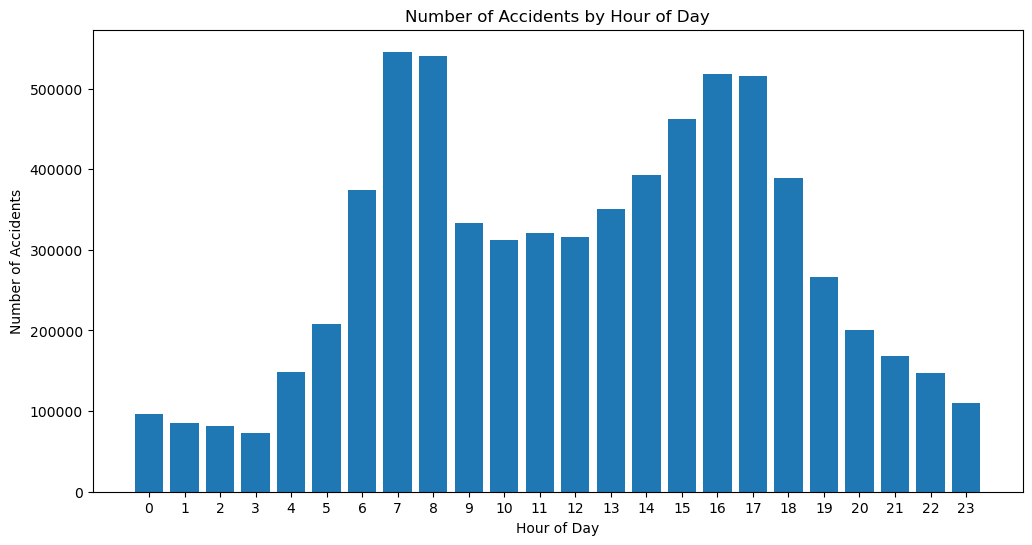

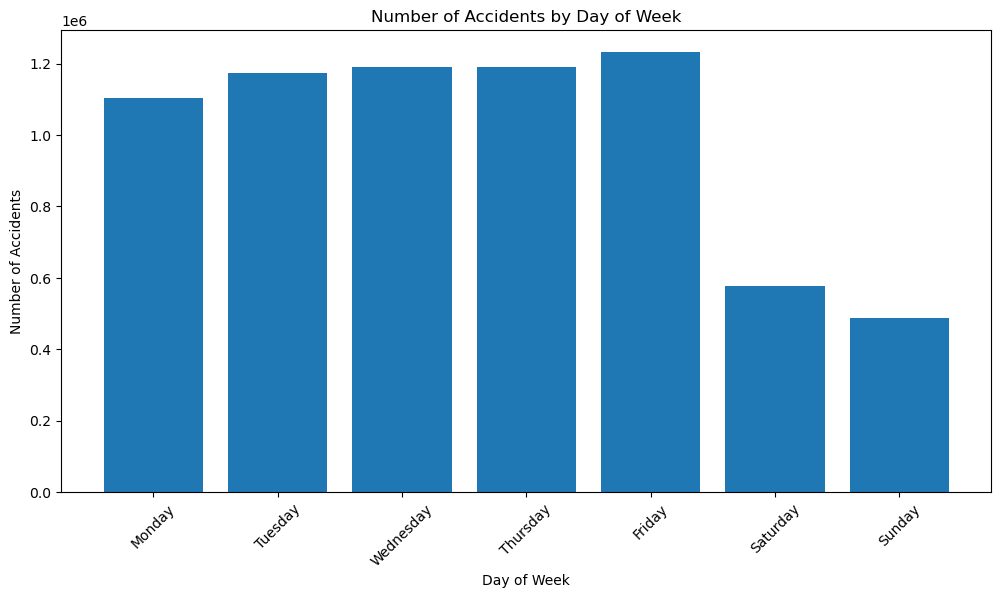

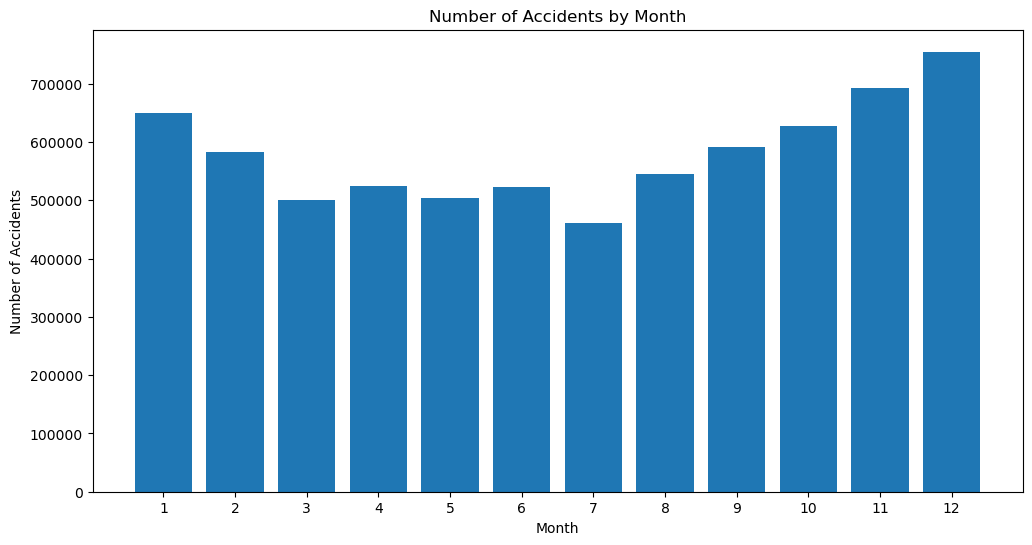

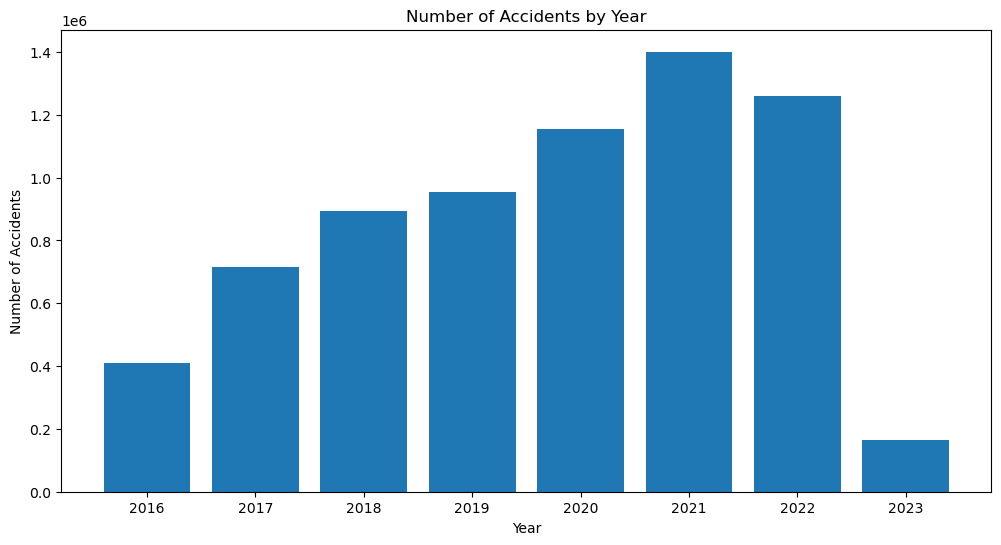

In [36]:
# Analyze accident patterns by hour, day of week, month, and year

# Set a larger default figure size
plt.figure(figsize=(12, 6))

# Accidents by hour of day
hour_counts = accidents["Start_Hour"].value_counts().sort_index()

plt.bar(hour_counts.index, hour_counts.values)
plt.title("Number of Accidents by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.show()

# Accidents by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = accidents["Start_Day"].value_counts().reindex(day_order, fill_value=0)

plt.figure(figsize=(12, 6))
plt.bar(day_counts.index, day_counts.values)
plt.title("Number of Accidents by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

# Accidents by month
month_counts = accidents["Start_Month"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(month_counts.index, month_counts.values)
plt.title("Number of Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accidents")
plt.xticks(range(1, 13))
plt.show()

# Accidents by year
year_counts = accidents["Start_Year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(year_counts.index, year_counts.values)
plt.title("Number of Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

### Time-Based Pattern Interpretation

The time-based visuals show that accidents are not evenly distributed throughout the day or week. Accident counts are highest during commute-related periods, especially around 7–8 AM and 4–5 PM. This suggests that traffic volume during workday travel periods may be an important factor in accident frequency.

The day-of-week chart shows that accidents are more common on weekdays than weekends, with Friday having the highest accident count. This supports the idea that workweek commuting and weekday traffic patterns are closely related to accident volume.

The monthly chart shows that accident counts generally increase toward the end of the year, with December having the highest count. This could be related to seasonal travel, holiday traffic, reduced daylight, or weather conditions. The yearly chart should be interpreted carefully because the 2023 data may not represent a full year.

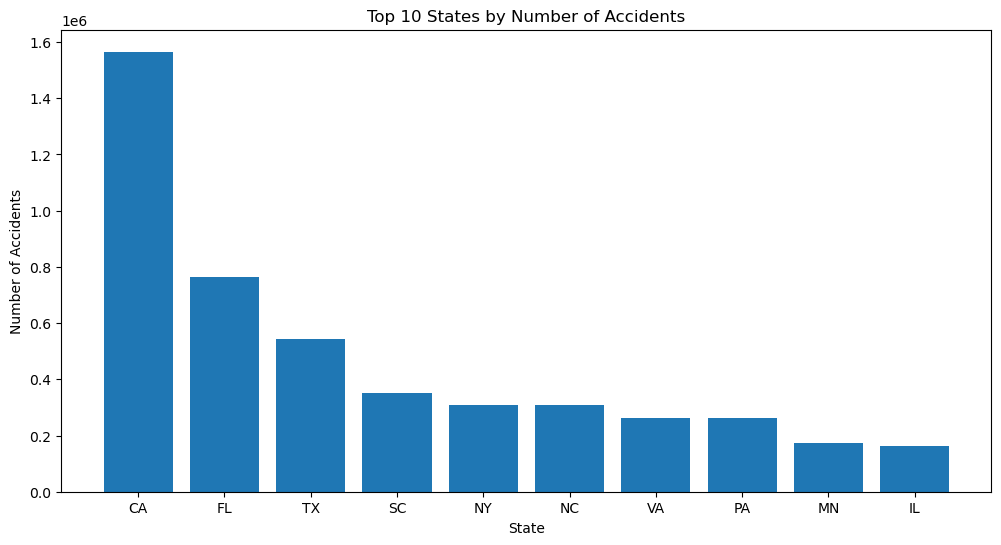

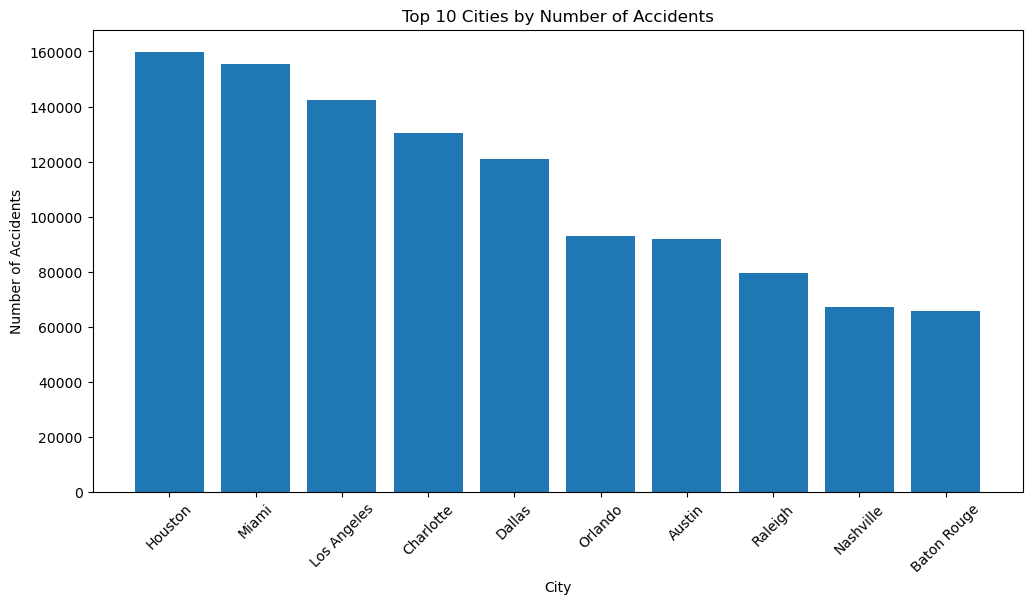

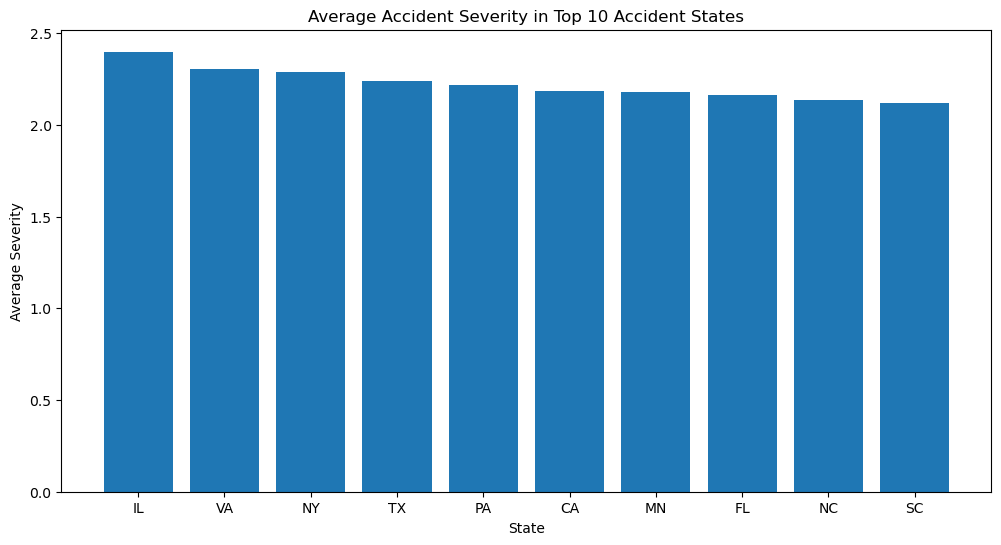

,accident_count,average_severity,average_duration_minutes
State,,,
CA,1565515,2.182321,108.164372
FL,762687,2.159523,129.431020
TX,544490,2.237510,90.903933
SC,350580,2.119274,80.888662
NY,309811,2.286229,111.613533
NC,309560,2.134866,105.377709
VA,261478,2.301616,102.601292
PA,260779,2.216620,100.360718
MN,171662,2.180081,102.501854


In [22]:
# Analyze accident patterns by state and city

# Top 10 states by accident count
top_states = accidents["State"].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_states.index, top_states.values)
plt.title("Top 10 States by Number of Accidents")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
plt.show()

# Top 10 cities by accident count
top_cities = accidents["City"].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_cities.index, top_cities.values)
plt.title("Top 10 Cities by Number of Accidents")
plt.xlabel("City")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

# Average severity by state for the top 10 accident states
top_state_names = top_states.index

avg_severity_by_state = (
    accidents[accidents["State"].isin(top_state_names)]
    .groupby("State")["Severity"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(avg_severity_by_state.index, avg_severity_by_state.values)
plt.title("Average Accident Severity in Top 10 Accident States")
plt.xlabel("State")
plt.ylabel("Average Severity")
plt.show()

# Summary table for top states
state_summary = accidents.groupby("State").agg(
    accident_count=("ID", "count"),
    average_severity=("Severity", "mean"),
    average_duration_minutes=("Duration_Minutes", "mean")
).sort_values(by="accident_count", ascending=False)

state_summary.head(10)

### Location-Based Pattern Interpretation

The location-based visuals show that accident volume is concentrated in specific states and cities. California has the highest number of accidents, followed by Florida and Texas. At the city level, Houston, Miami, Los Angeles, Charlotte, and Dallas are among the highest accident-count locations.

This does not necessarily mean these places are inherently more dangerous. Higher accident counts may also reflect larger populations, higher traffic volume, more road miles, or different reporting practices. However, these locations are still important from a business perspective because they represent areas where targeted safety reviews and resource allocation may have the greatest impact.

The average severity comparison also shows that high accident volume and high average severity are not always the same thing. This means transportation agencies should consider both accident frequency and severity when deciding where to prioritize interventions.

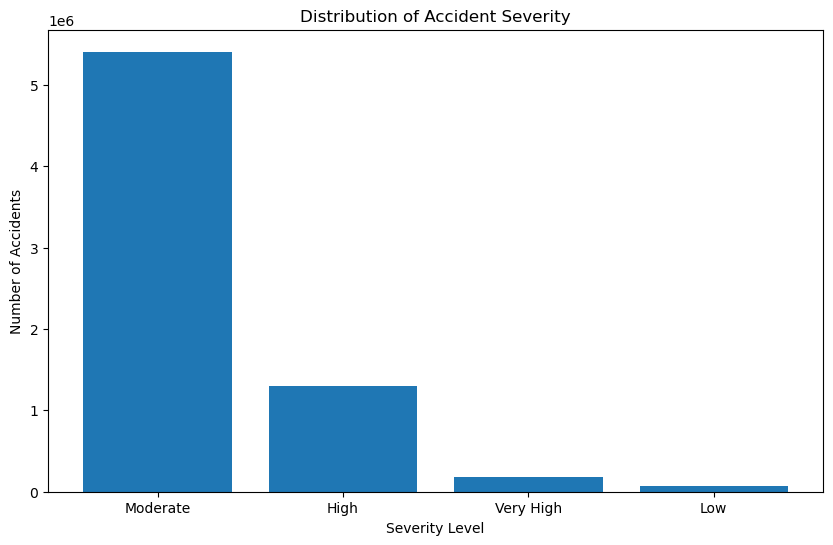

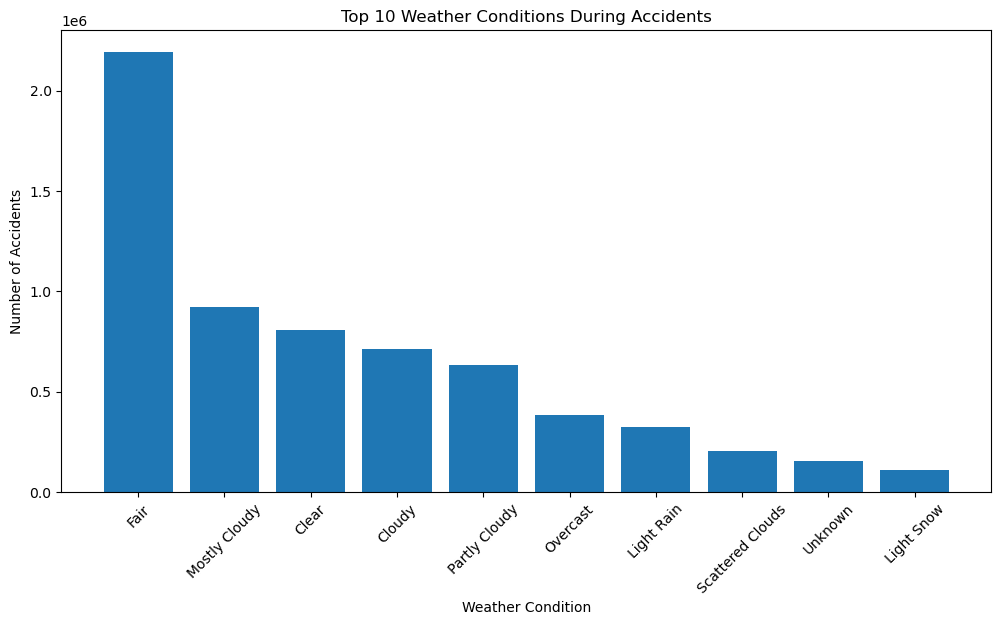

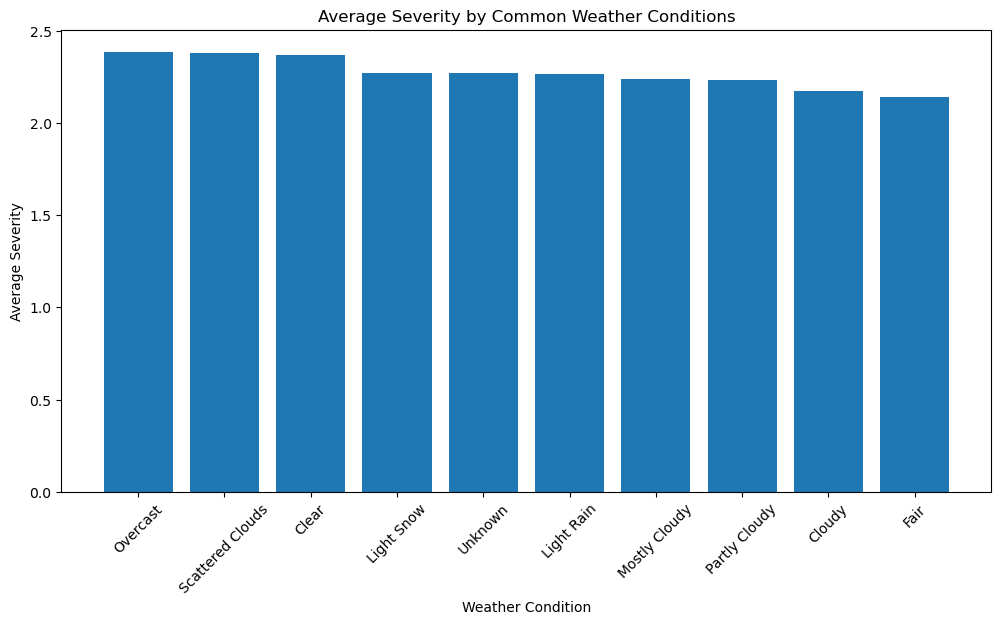

,accident_count,average_severity,average_visibility,average_duration_minutes
Sunrise_Sunset,,,,
Day,4818661,2.226320,9.195604,102.121472
Night,2120525,2.235842,8.929852,114.509227
Unknown,17195,2.216982,9.081956,124.066901


In [23]:
 # Analyze weather and environmental factors

# Severity distribution
severity_counts = accidents["Severity_Label"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(severity_counts.index, severity_counts.values)
plt.title("Distribution of Accident Severity")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")
plt.show()

# Top 10 weather conditions by accident count
top_weather = accidents["Weather_Condition"].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_weather.index, top_weather.values)
plt.title("Top 10 Weather Conditions During Accidents")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

# Average severity by top weather conditions
top_weather_names = top_weather.index

avg_severity_by_weather = (
    accidents[accidents["Weather_Condition"].isin(top_weather_names)]
    .groupby("Weather_Condition")["Severity"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(avg_severity_by_weather.index, avg_severity_by_weather.values)
plt.title("Average Severity by Common Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Average Severity")
plt.xticks(rotation=45)
plt.show()

# Compare severity by day/night
sunlight_severity = accidents.groupby("Sunrise_Sunset").agg(
    accident_count=("ID", "count"),
    average_severity=("Severity", "mean"),
    average_visibility=("Visibility(mi)", "mean"),
    average_duration_minutes=("Duration_Minutes", "mean")
).sort_values(by="accident_count", ascending=False)

sunlight_severity

### Weather, Severity, and Daylight Interpretation

The severity distribution shows that most accidents are classified as Moderate, followed by High. Low and Very High severity accidents are much less common in the prepared dataset. This helps establish the overall severity profile of the accidents being analyzed.

The weather visuals show that many accidents occur during common weather conditions such as Fair, Mostly Cloudy, Clear, and Cloudy. This should be interpreted carefully because these conditions may simply occur more often overall. A high accident count during fair weather does not automatically mean fair weather causes more accidents.

The daylight comparison suggests that nighttime accidents have slightly higher average severity and longer average duration than daytime accidents. The difference is not extremely large, but it may still be useful as an operational insight because longer accident duration can affect road clearance, congestion, and emergency response planning.

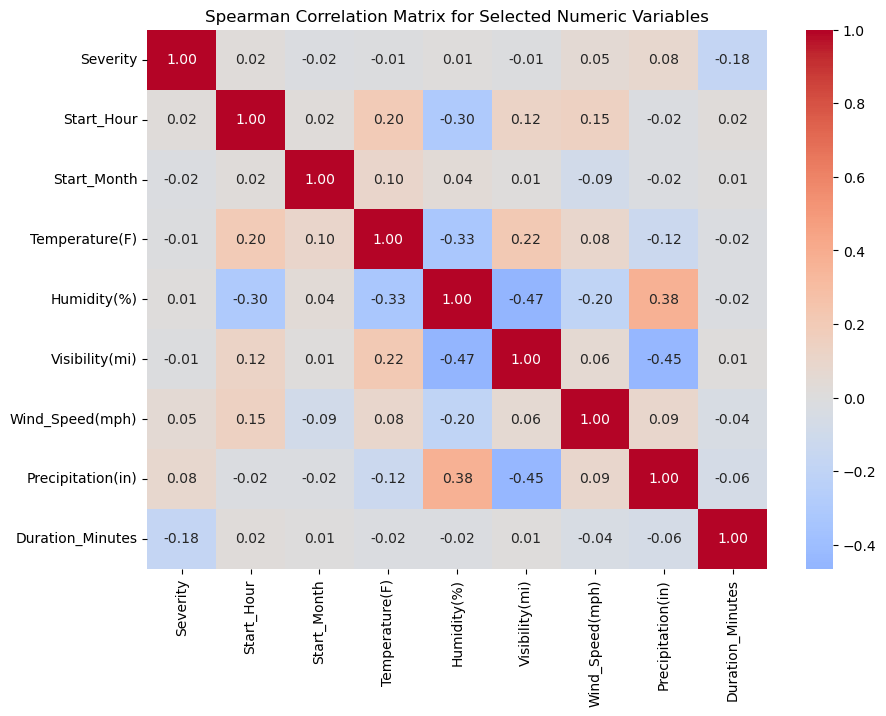

In [37]:
# Correlation matrix for selected numeric variables

correlation_columns = [
    "Severity",
    "Start_Hour",
    "Start_Month",
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Duration_Minutes"
]

correlation_matrix = accidents[correlation_columns].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix for Selected Numeric Variables")
plt.show()

### Correlation Matrix Interpretation

The correlation matrix provides a broader view of relationships between selected numeric variables. Spearman correlation was used because some variables, such as severity, are ordinal and may not have a linear relationship with other fields.

Most of the correlations appear weak, which suggests that no single numeric variable strongly explains accident severity or accident duration by itself. This supports using multiple views of the data, including time, location, weather, and daylight status, rather than relying on one factor alone.

In [39]:
# Statistical analysis to test relationships between selected variables

from scipy.stats import chi2_contingency, f_oneway, spearmanr, levene, kruskal
from statsmodels.stats.multitest import multipletests

# 1. Chi-square test: Severity_Label vs Sunrise_Sunset
# This tests whether accident severity category is related to day/night status.

contingency_table = pd.crosstab(accidents["Severity_Label"], accidents["Sunrise_Sunset"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test: Severity Label vs Sunrise/Sunset")
print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

if p_value < 0.05:
    print("Result: There is a statistically significant relationship between severity and sunrise/sunset status.")
else:
    print("Result: There is not enough evidence to show a statistically significant relationship.")


# 2. ANOVA assumption check and ANOVA test
# ANOVA compares average accident duration across severity groups.
# Before running ANOVA, Levene's test checks whether group variances are similar.

severity_groups = [
    group["Duration_Minutes"].dropna()
    for name, group in accidents.groupby("Severity_Label")
]

levene_stat, levene_p = levene(*severity_groups)

print("\nLevene's Test: Equal Variance Check for Duration by Severity Label")
print("Levene statistic:", levene_stat)
print("p-value:", levene_p)

if levene_p < 0.05:
    print("Result: Variances are significantly different. ANOVA should be interpreted with caution.")
else:
    print("Result: Variances are not significantly different. ANOVA assumption is more reasonable.")


# ANOVA test: Compare average duration across severity levels
# This tests whether accident duration differs across severity groups.

anova_stat, anova_p = f_oneway(*severity_groups)

print("\nANOVA Test: Duration Minutes by Severity Label")
print("ANOVA statistic:", anova_stat)
print("p-value:", anova_p)

if anova_p < 0.05:
    print("Result: Average accident duration differs significantly across severity groups.")
else:
    print("Result: There is not enough evidence to show a significant difference in duration across severity groups.")


# Nonparametric backup test
# Kruskal-Wallis is useful when ANOVA assumptions are questionable.

kruskal_stat, kruskal_p = kruskal(*severity_groups)

print("\nKruskal-Wallis Test: Duration Minutes by Severity Label")
print("Kruskal-Wallis statistic:", kruskal_stat)
print("p-value:", kruskal_p)

if kruskal_p < 0.05:
    print("Result: Accident duration differs significantly across severity groups using a nonparametric test.")
else:
    print("Result: There is not enough evidence to show a significant difference across severity groups.")


# 3. Spearman correlation: Weather-related numeric variables and severity
# Spearman correlation is used because severity is ordinal.
# Rows with missing values are dropped separately for each variable.

numeric_columns = [
    "Temperature(F)",
    "Humidity(%)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Duration_Minutes"
]

correlation_results = []

for col in numeric_columns:
    temp_df = accidents[["Severity", col]].dropna()
    
    corr, p = spearmanr(temp_df["Severity"], temp_df[col])
    
    correlation_results.append({
        "variable": col,
        "spearman_correlation_with_severity": corr,
        "p_value": p,
        "rows_used": len(temp_df)
    })

correlation_df = pd.DataFrame(correlation_results)

# Multiple-testing correction for Spearman correlation p-values
# This reduces the chance of false positives when testing several variables.

correlation_df["adjusted_p_value_bh"] = multipletests(
    correlation_df["p_value"],
    method="fdr_bh"
)[1]

correlation_df["significant_after_correction"] = correlation_df["adjusted_p_value_bh"] < 0.05

correlation_df = correlation_df.sort_values(
    by="spearman_correlation_with_severity",
    ascending=False
)

correlation_df

Chi-Square Test: Severity Label vs Sunrise/Sunset
Chi-square statistic: 17862.828900037144
p-value: 0.0
Degrees of freedom: 3
Result: There is a statistically significant relationship between severity and sunrise/sunset status.

Levene's Test: Equal Variance Check for Duration by Severity Label
Levene statistic: 59963.89397153316
p-value: 0.0
Result: Variances are significantly different. ANOVA should be interpreted with caution.

ANOVA Test: Duration Minutes by Severity Label
ANOVA statistic: 83004.0937776729
p-value: 0.0
Result: Average accident duration differs significantly across severity groups.

Kruskal-Wallis Test: Duration Minutes by Severity Label
Kruskal-Wallis statistic: 503444.9965700011
p-value: 0.0
Result: Accident duration differs significantly across severity groups using a nonparametric test.


,variable,spearman_correlation_with_severity,p_value,rows_used,adjusted_p_value_bh,significant_after_correction
4,Precipitation(in),0.081513,0.000000e+00,4785352,0.000000e+00,True
3,Wind_Speed(mph),0.053243,0.000000e+00,6408131,0.000000e+00,True
1,Humidity(%),0.013748,1.484239e-281,6801732,2.226358e-281,True
0,Temperature(F),-0.009859,5.262231e-146,6810940,5.262231e-146,True
2,Visibility(mi),-0.010803,1.391636e-174,6798999,1.669963e-174,True
5,Duration_Minutes,-0.176995,0.000000e+00,6956381,0.000000e+00,True


### Statistical Assumption Check and Interpretation

The chi-square test showed a statistically significant relationship between accident severity and sunrise/sunset status. This suggests that daylight status is related to accident severity category, although this does not prove causation.

Because ANOVA assumes similar variance across groups, I used Levene's test to check whether accident duration had equal variance across severity groups. The Levene test showed that variances were significantly different, so the ANOVA result should be interpreted with caution.

I also used the Kruskal-Wallis test as a nonparametric alternative because it does not rely on the same variance assumptions as ANOVA. This test also showed a significant difference in accident duration across severity groups, which supports the finding that duration varies by severity level.

Because several Spearman correlations were tested, I applied a Benjamini-Hochberg correction to reduce the risk of false positives. Although all tested variables remained statistically significant after correction, most correlation values were weak. This means the relationships are statistically detectable because the dataset is very large, but they should not be overstated as strong practical effects.

In [25]:
# Create a simple summary table of key analysis findings

analysis_findings = pd.DataFrame({
    "Analysis Area": [
        "Time of Day",
        "Day of Week",
        "Month",
        "Location - State",
        "Location - City",
        "Severity",
        "Day vs Night",
        "Statistical Testing"
    ],
    "Key Finding": [
        "Accidents peak around morning and afternoon commute hours.",
        "Weekdays have more accidents than weekends, with Friday highest.",
        "Accident counts increase toward the end of the year, with December highest.",
        "California, Florida, and Texas have the highest accident counts.",
        "Houston, Miami, and Los Angeles are among the highest accident-count cities.",
        "Most accidents are Moderate severity, followed by High severity.",
        "Night accidents have slightly higher average severity and longer average duration than day accidents.",
        "Severity has statistically significant relationships with daylight status and accident duration, but most numeric correlations are weak."
    ],
    "Business Relevance": [
        "Supports commute-hour traffic safety interventions.",
        "Supports weekday-focused safety planning.",
        "Supports seasonal safety campaigns and winter/holiday traffic planning.",
        "Supports state-level resource prioritization.",
        "Supports city-level hotspot investigation.",
        "Helps focus on common accident severity patterns.",
        "Supports nighttime visibility and response-time recommendations.",
        "Provides evidence for findings while avoiding overclaiming causation."
    ]
})

analysis_findings

,Analysis Area,Key Finding,Business Relevance
0,Time of Day,Accidents peak around morning and afternoon co...,Supports commute-hour traffic safety intervent...
1,Day of Week,"Weekdays have more accidents than weekends, wi...",Supports weekday-focused safety planning.
2,Month,Accident counts increase toward the end of the...,Supports seasonal safety campaigns and winter/...
3,Location - State,"California, Florida, and Texas have the highes...",Supports state-level resource prioritization.
4,Location - City,"Houston, Miami, and Los Angeles are among the ...",Supports city-level hotspot investigation.
5,Severity,"Most accidents are Moderate severity, followed...",Helps focus on common accident severity patterns.
6,Day vs Night,Night accidents have slightly higher average s...,Supports nighttime visibility and response-tim...
7,Statistical Testing,Severity has statistically significant relatio...,Provides evidence for findings while avoiding ...


### Analysis Summary

Overall, the analysis identified the strongest practical patterns in accident timing, location, severity, weather, and daylight conditions. Accident counts were highest during weekday commute periods, especially around 7–8 AM and 4–5 PM. Accidents were also concentrated in specific high-volume states and cities, including California, Florida, Texas, Houston, Miami, and Los Angeles.

The severity analysis showed that most accidents were Moderate severity, while the daylight and duration analysis suggested that nighttime accidents may take longer to clear on average than daytime accidents. Weather-related findings should be interpreted carefully because common weather conditions may have high accident counts simply because they occur more often.

The correlation matrix and statistical testing suggest that many relationships are statistically significant but weak in practical strength. Because this dataset is very large, small effects can appear statistically significant. I also added assumption checking for the ANOVA test using Levene's test and confirmed the duration finding with a Kruskal-Wallis nonparametric test. For the Spearman correlations, I applied a Benjamini-Hochberg correction to reduce the risk of false positives from multiple testing.

For this reason, the final recommendations focus on the clearest practical patterns: commute-hour safety, high-accident locations, and nighttime visibility and response planning.

## Export Cleaned Data for Tableau

The cleaned dataset is exported below so it can be used to build the Tableau dashboard.

In [ ]:
# Export cleaned dataset for Tableau dashboard
accidents.to_csv("cleaned_us_accidents_for_tableau.csv", index=False)

## Tableau Dashboard Link

The interactive Tableau dashboard for this project can be viewed here:

[US Traffic Accident Analysis Dashboard](https://public.tableau.com/app/profile/anna.lunova/viz/USTrafficAccidentAnalysisDashboard_17814932002320/USTrafficAccidentDashboard?publish=yes)

The Tableau dashboard uses the cleaned accident dataset to show patterns by time, location, severity, and duration. Location-based views use raw accident counts, so they should be interpreted as high-volume accident areas rather than normalized risk rates. Future dashboard improvements could include population, traffic volume, or vehicle miles traveled data to calculate accident rates by location.

## Evaluation

### Business Insight/Recommendation 1: Target Weekday Commute-Hour Safety Interventions

The analysis showed that accidents are most common during morning and afternoon commute periods, especially around 7–8 AM and 4–5 PM. Accidents also occur more often during weekdays than weekends, with Friday showing the highest accident count.

Based on this finding, the Department of Transportation should focus safety efforts on weekday commute periods. This could include targeted digital message signs, improved signal timing, temporary traffic monitoring, and public safety messaging during high-risk hours.

Potential KPIs include reducing commute-hour accident counts by 5–10% in targeted corridors, reducing average incident duration during peak hours, and tracking changes in accident counts before and after interventions.

### Business Insight/Recommendation 2: Prioritize High-Volume Accident Locations for Local Safety Reviews

The location analysis showed that accidents are concentrated in certain states and cities, including California, Florida, Texas, Houston, Miami, Los Angeles, Charlotte, and Dallas. These locations should be prioritized for deeper local safety reviews because they represent major accident concentration points in the dataset.

However, this recommendation is based on raw accident counts. High accident counts may reflect larger populations, higher traffic volume, more road miles, or different reporting practices. Before making major infrastructure decisions, accident counts should be normalized by population, traffic volume, or vehicle miles traveled.

Potential KPIs include reducing accidents in selected high-volume corridors, lowering repeat-accident hotspot counts, and comparing accident rates before and after safety improvements.

### Business Insight/Recommendation 3: Improve Nighttime Visibility and Incident Response Planning

The analysis showed that nighttime accidents had longer average duration than daytime accidents. While the difference is not extremely large, it may still indicate operational challenges related to visibility, incident detection, road clearance, or emergency response coordination.

Based on this finding, transportation agencies should review nighttime accident hotspots and consider improvements such as better lighting, reflective lane markings, clearer signage, and faster incident detection.

Potential KPIs include reducing average nighttime accident duration, improving incident clearance time, reducing the percentage of high-severity nighttime accidents, and tracking emergency response performance before and after improvements.

## Conclusion and Next Steps

This project analyzed the US Accidents dataset to identify patterns related to accident timing, location, weather conditions, daylight status, and severity. The analysis showed that accidents are more common during weekday commute hours, especially in the morning and late afternoon. Accidents were also concentrated in specific states and cities, with California, Florida, Texas, Houston, Miami, and Los Angeles appearing as major high-volume areas.

The analysis also showed that most accidents were classified as Moderate severity, but nighttime accidents had slightly higher average severity and longer average duration than daytime accidents. Statistical testing supported that accident severity has a significant relationship with sunrise/sunset status, and that accident duration differs across severity groups. However, some numeric relationships were weak, so the results should be interpreted carefully and not treated as proof of direct causation.

Based on these findings, the main recommendations are to focus safety efforts during commute hours, prioritize high-accident locations for deeper local analysis, and improve nighttime visibility and response planning. These recommendations are intended to help transportation agencies use data to target safety improvements where they may have the greatest impact.

### Next Steps

Future analysis could improve this project by adding more local traffic, population, and road infrastructure data. This would help determine whether high accident counts are related to traffic volume, population density, road design, or other local factors. A more detailed hotspot analysis could also be performed using latitude and longitude to identify specific roads, intersections, or corridors with frequent accidents.

Another next step would be to build and publish the Tableau dashboard so stakeholders can explore accident patterns interactively. The dashboard should include filters for state, city, severity, time of day, weather condition, and daylight status. This would make the findings easier for non-technical users to understand and apply in decision-making.